In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os
os.chdir(r"D:\code\github\strainOptimizer")

In [2]:
# set the font size of the figure
plt.rcParams['font.family'] = 'Arial'
# plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 1

axis_fontdict={'fontsize':8,'fontweight':'bold'}
label_fontdict={'fontsize':10,'fontweight':'bold'}
title_fontdict={'fontsize':12,'fontweight':'bold'}

# colors_set=sns.color_palette('colorblind')
colors_paired=sns.color_palette("Paired")
colors_compare=sns.color_palette('colorblind')
# colors_paired
colors_compare

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

### Figure 3A.

In [3]:
df_enzyme_mass_fraction=pd.read_csv(r'D:\code\github\strainOptimizer\analysis_code/results/sce_enzyme_mass_fraction.csv',index_col=0)
df_enzyme_mass_fraction.head()

,Glucose_phase_rep1(g/gDW),Glucose_phase_rep2(g/gDW),Glucose_phase_rep3(g/gDW),Diauxic_shift_rep1(g/gDW),Diauxic_shift_rep2(g/gDW),Diauxic_shift_rep3(g/gDW),Ethanol_phase_rep1(g/gDW),Ethanol_phase_rep2(g/gDW),Ethanol_phase_rep3(g/gDW),Min_aerobic_1,...,oleate(mmol/gDW),fructose(mmol/gDW),sucrose(mmol/gDW),trehalose(mmol/gDW),lactate(mmol/gDW),acetate(mmol/gDW),pryuvate(mmol/gDW),glycerol(mmol/gDW),galactose(mmol/gDW),raffinose(mmol/gDW)
compartment,,,,,,,,,,,,,,,,,,,,,
nucleus,0.118119,0.116983,0.117875,0.076279,0.075370,0.077957,0.072655,0.074308,0.074819,0.055379,...,0.058038,0.055427,0.058553,0.058668,0.061703,0.046010,0.062349,0.058678,0.060975,0.055084
mitochondrion,0.242237,0.240234,0.241432,0.308085,0.311675,0.312958,0.306108,0.305334,0.303359,0.215751,...,0.388809,0.251683,0.247437,0.415075,0.397251,0.454343,0.381355,0.415940,0.259236,0.312402
membrane,0.036284,0.035079,0.036190,0.073970,0.077192,0.080907,0.064501,0.064575,0.065206,0.036365,...,0.066374,0.049519,0.050163,0.067711,0.064931,0.088735,0.071908,0.075594,0.063383,0.066289
cytosol,0.179836,0.177731,0.178796,0.180430,0.177879,0.176843,0.162317,0.164555,0.160552,0.099227,...,0.158417,0.121766,0.113081,0.163949,0.159215,0.163238,0.153806,0.130010,0.093272,0.098457
cytoplasm,0.279827,0.282840,0.278566,0.272789,0.274674,0.269273,0.315355,0.308281,0.315330,0.286781,...,0.240761,0.270909,0.246728,0.246269,0.241392,0.201035,0.222166,0.213310,0.228849,0.220186


C:\Users\wangh\AppData\Local\Temp\ipykernel_480\3032420157.py:11: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.boxplot(data=data,ax=ax,showfliers=False,orient='h',palette=colors_compare)
C:\Users\wangh\AppData\Local\Temp\ipykernel_480\3032420157.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=10,weight='bold')


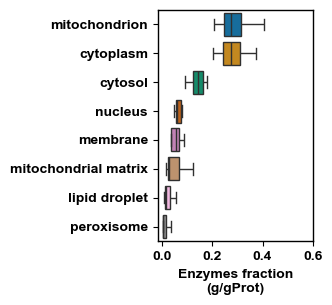

In [4]:
data=df_enzyme_mass_fraction.T
# ignore columns with mean value < 0.05
data = data.loc[:, data.mean(axis=0) > 0.01]

# sort according to the mean value
data = data.reindex(data.mean().sort_values(ascending=False).index, axis=1)

fig,ax=plt.subplots(figsize=(2,3))

# plot the distribution for each compartment(rows), 横向绘制
sns.boxplot(data=data,ax=ax,showfliers=False,orient='h',palette=colors_compare)

# rotate x tick
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=10,weight='bold')
ax.set_ylabel('')
ax.set_xlabel('Enzymes fraction\n(g/gProt)',label_fontdict)
# set y ticks: 0,0.2
ax.set_xticks(np.arange(0,0.8,0.2))
# set x ticks label
ax.set_xticklabels(ax.get_xticklabels(),fontsize=10,weight='bold')

# save it
fig.savefig(r'analysis_code\figures\output/figure3a_subcellular_enzymeFraction.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

### Figure 3C

In [4]:
df_result=pd.read_csv(r'analysis_code\results/ecGEM_organelle_proteome_constraint_evaluation.csv',index_col=1)
df_result.head()

,Unnamed: 0,product_name,organelle_constraint,level,consistency,precision,predict_num,average_distance,connectivity_score
model_type,,,,,,,,,
ecGEM,0,2-phenylethanol,yes,l1,0.538462,0.095890,73,6.113514,19.479452
ecGEM,1,2-phenylethanol,yes,l2,0.538462,0.116667,60,6.053352,19.833333
ecGEM,2,2-phenylethanol,yes,l3,0.384615,0.217391,23,6.300000,8.782609
ecGEM,3,2-phenylethanol,yes,fcc,0.307692,0.400000,10,5.890000,12.500000
ecGEM,4,2-phenylethanol,without mitochondria,l1,0.538462,0.125000,56,6.149658,22.714286


C:\Users\wangh\AppData\Local\Temp\ipykernel_6048\1132195951.py:10: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='consistency',hue='organelle_constraint',data=df_select,ax=axs[0],order=product_name_order.keys(),palette=colors_compare)
C:\Users\wangh\AppData\Local\Temp\ipykernel_6048\1132195951.py:23: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='precision',hue='organelle_constraint',data=df_select,ax=axs[1],legend=False,order=product_name_order.keys(),palette=colors_compare)
C:\Users\wangh\AppData\Local\Temp\ipykernel_6048\1132195951.py:31: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='predict_num',hue='organelle_constraint',data=df_select,ax=axs[2],legend=False,order=product_name_order.keys(),palette=colors_compare)
C:\Users\wangh\AppData\Lo

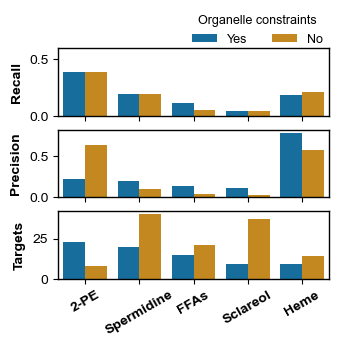

In [25]:
df_select=df_result[df_result['level']=='l3']
df_select=df_select[df_select['organelle_constraint']!='without mitochondria']
# fill yes as Yes, no as No
df_select['organelle_constraint']=df_select['organelle_constraint'].map({'yes':'Yes','no':'No'})

fig,axs=plt.subplots(3,1,figsize=(3.5,3))

product_name_order ={'2-phenylethanol':0,'spermidine':1,'ffa':2,'sclareol':3,'heme':4}
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='organelle_constraint',data=df_select,ax=axs[0],order=product_name_order.keys(),palette=colors_compare)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',fontweight='bold',fontsize=10)
# set legend outside 
# fill as Yes, No
axs[0].legend(title='Organelle constraints',bbox_to_anchor=(1, 1.58), borderaxespad=0.1,fontsize=9,title_fontsize=9,
                frameon=False,
                ncol=2)
axs[0].set_ylim(0,0.6)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='organelle_constraint',data=df_select,ax=axs[1],legend=False,order=product_name_order.keys(),palette=colors_compare)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',fontweight='bold',fontsize=10,labelpad=5)


# plot experiment predict num
sns.barplot(x='product_name',y='predict_num',hue='organelle_constraint',data=df_select,ax=axs[2],legend=False,order=product_name_order.keys(),palette=colors_compare)
# set x, y ticks
# set x ticks
x_ticks_dict={'2-phenylethanol':'2-PE',
              'heme':'Heme',
              'ffa':'FFAs',
              'sclareol':'Sclareol',
              'spermidine':'Spermidine'}
x_ticks_list=[x_ticks_dict[i] for i in product_name_order.keys()]
axs[2].set_xticklabels(rotation=30,labels=x_ticks_list,fontweight='bold',fontsize=10)
axs[2].set_xlabel('')
axs[2].set_ylabel('Targets',fontweight='bold',fontsize=10,labelpad=5)

# fig.suptitle('ecFactory-L3',fontweight='bold',fontsize=12)
# plt.tight_layout()
# save it
fig.savefig(r'analysis_code\figures\output/figure3c_organelle_proteome_constraint_evaluation_l3.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

In [7]:
df_select

,Unnamed: 0,product_name,organelle_constraint,level,consistency,precision,predict_num,average_distance,connectivity_score
model_type,,,,,,,,,
ecGEM,2,2-phenylethanol,Yes,l3,0.384615,0.217391,23,6.300000,8.782609
ecGEM,10,ffa,Yes,l3,0.111111,0.133333,15,7.339762,19.266667
ecGEM,18,heme,Yes,l3,0.184211,0.777778,9,6.538462,8.692308
ecGEM,26,sclareol,Yes,l3,0.045455,0.111111,9,6.020833,12.555556
ecGEM,34,spermidine,Yes,l3,0.190476,0.200000,20,6.445833,32.200000
ecGEM,42,2-phenylethanol,No,l3,0.384615,0.625000,8,6.268750,46.750000
ecGEM,46,ffa,No,l3,0.055556,0.047619,21,7.437500,5.571429
ecGEM,50,heme,No,l3,0.210526,0.571429,14,6.178571,6.500000
ecGEM,54,sclareol,No,l3,0.045455,0.027027,37,7.048872,18.027027


C:\Users\wangh\AppData\Local\Temp\ipykernel_480\2751108001.py:10: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='consistency',hue='organelle_constraint',data=df_select,ax=axs[0],order=product_name_order.keys(),palette=colors_compare)
C:\Users\wangh\AppData\Local\Temp\ipykernel_480\2751108001.py:23: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='precision',hue='organelle_constraint',data=df_select,ax=axs[1],legend=False,order=product_name_order.keys(),palette=colors_compare)
C:\Users\wangh\AppData\Local\Temp\ipykernel_480\2751108001.py:31: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(x='product_name',y='predict_num',hue='organelle_constraint',data=df_select,ax=axs[2],legend=False,order=product_name_order.keys(),palette=colors_compare)
C:\Users\wangh\AppData\Local

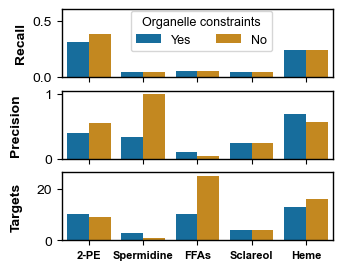

In [8]:
df_select=df_result[df_result['level']=='fcc']
df_select=df_select[df_select['organelle_constraint']!='without mitochondria']
# fill yes as Yes, no as No
df_select['organelle_constraint']=df_select['organelle_constraint'].map({'yes':'Yes','no':'No'})

fig,axs=plt.subplots(3,1,figsize=(3.5,3))

product_name_order ={'2-phenylethanol':0,'spermidine':1,'ffa':2,'sclareol':3,'heme':4}
# plot experiment constency
sns.barplot(x='product_name',y='consistency',hue='organelle_constraint',data=df_select,ax=axs[0],order=product_name_order.keys(),palette=colors_compare)
# remove x tick and label
axs[0].set_xticklabels([])
axs[0].set_xlabel('')
axs[0].set_ylabel('Recall',fontweight='bold',fontsize=10)
# set legend outside 
# fill as Yes, No
axs[0].legend(title='Organelle constraints',bbox_to_anchor=(0.25, 1), borderaxespad=0.1,fontsize=9,title_fontsize=9,
                frameon=True,
                ncol=2)
axs[0].set_ylim(0,0.6)

# plot experiment accuracy
sns.barplot(x='product_name',y='precision',hue='organelle_constraint',data=df_select,ax=axs[1],legend=False,order=product_name_order.keys(),palette=colors_compare)
# remove x tick and label
axs[1].set_xticklabels([])
axs[1].set_xlabel('')
axs[1].set_ylabel('Precision',fontweight='bold',fontsize=10,labelpad=16)


# plot experiment predict num
sns.barplot(x='product_name',y='predict_num',hue='organelle_constraint',data=df_select,ax=axs[2],legend=False,order=product_name_order.keys(),palette=colors_compare)
# set x, y ticks
# set x ticks
x_ticks_dict={'2-phenylethanol':'2-PE',
              'heme':'Heme',
              'ffa':'FFAs',
              'sclareol':'Sclareol',
              'spermidine':'Spermidine'}
x_ticks_list=[x_ticks_dict[i] for i in product_name_order.keys()]
axs[2].set_xticklabels(rotation=0,labels=x_ticks_list,fontweight='bold',fontsize=8)
axs[2].set_xlabel('')
axs[2].set_ylabel('Targets',fontweight='bold',fontsize=10,labelpad=10)

# fig.suptitle('ecFactory-L3',fontweight='bold',fontsize=12)
# plt.tight_layout()
# save it
fig.savefig(r'analysis_code\figures\output/figureS4_organelle_proteome_constraint_evaluation_fcc.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

### Figure 3D

In [26]:
df_heme=df_result[df_result['product_name']=='heme']
df_heme_l3=df_heme[df_heme['level']=='l3']
df_heme_fcc=df_heme[df_heme['level']=='fcc']
df_heme_fcc
# df_heme_l3

,Unnamed: 0,product_name,organelle_constraint,level,consistency,precision,predict_num,average_distance,connectivity_score
model_type,,,,,,,,,
ecGEM,19,heme,yes,fcc,0.236842,0.692308,13,5.692308,3.0
ecGEM,23,heme,without mitochondria,fcc,0.236842,0.529412,17,6.250000,3.0
ecGEM,51,heme,no,fcc,0.236842,0.562500,16,5.783333,3.0


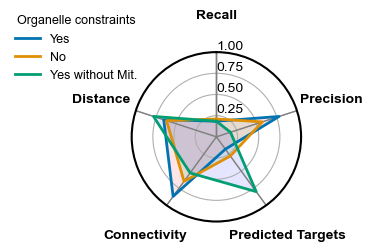

In [31]:
from math import pi
# plot radar chart
fig,ax=plt.subplots(figsize=(2.8,2.2),subplot_kw=dict(polar=True,frameon=True))
# plt.style.use('seaborn-paper')

# number of variable
categories=['consistency','precision','predict_num','connectivity_score','average_distance']
scale_factors=[1,1,50,10,10]
# scaling the data
df_data_scaled=df_heme_l3.copy()
df_data_scaled[categories]=df_data_scaled[categories]/scale_factors
N = len(categories)

# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw one axis per variable + add labels, set the label position, and make tick labels farther apart
# plt.xticks(angles[:-1], categories, size=10,fontweight="bold",color="black")
plt.xticks(angles[:-1], ['Recall','Precision','Predicted Targets','Connectivity','Distance'], size=10,fontweight="bold",color="black",
           position=(0, -0.2))
# set x axis line color
ax.spines['polar'].set_color('black')
ax.spines['polar'].set_linewidth(1.5)

# Draw ylabels
ax.set_rlabel_position(0) 
plt.yticks([0.25,0.50,0.75,1.00], size=10)
# don't show tick
# ax.set_yticks([])

plt.ylim(0, 1)

# plot 5 line x=angles,y=1
for angle in angles:
    ax.plot([angle, angle], [0, 1], linewidth=1, linestyle='solid', color='grey')

# Add constrint
values = df_data_scaled[df_data_scaled['organelle_constraint']=='yes'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Yes",color=colors_compare[0])
ax.fill(angles, values, 'red', alpha=0.1)

# No constraint
values = df_data_scaled[df_data_scaled['organelle_constraint']=='no'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="No",color=colors_compare[1])
ax.fill(angles, values, 'green', alpha=0.1)

# yes without mitochondria
values = df_data_scaled[df_data_scaled['organelle_constraint']=='without mitochondria'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Yes without Mit.",color=colors_compare[2])
ax.fill(angles, values, 'blue', alpha=0.1)

# set legend for ax
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 1.29),fontsize=9,ncol=1,frameon=False,title='Organelle constraints',title_fontsize=9)

# set title
# plt.title("Heme a prediction by ecFactory",fontsize=12,fontweight="bold",color="black")
# save it
fig.savefig(r'analysis_code\figures\output/figure3d_organelle_proteome_constraint_evaluation_heme_l3.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()

### Suplementary Figure 4a

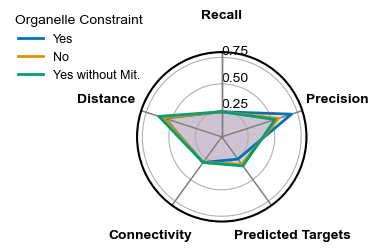

In [30]:
# plot radar chart
fig,ax=plt.subplots(figsize=(2.8,2.2),subplot_kw=dict(polar=True,frameon=True))
# plt.style.use('seaborn-paper')

# number of variable
categories=['consistency','precision','predict_num','connectivity_score','average_distance']
scale_factors=[1,1,50,10,10]
# scaling the data
df_data_scaled=df_heme_fcc.copy()
df_data_scaled[categories]=df_data_scaled[categories]/scale_factors
N = len(categories)

# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Draw one axis per variable + add labels, set the label position, and make tick labels farther apart
# plt.xticks(angles[:-1], categories, size=10,fontweight="bold",color="black")
plt.xticks(angles[:-1], ['Recall','Precision','Predicted Targets','Connectivity','Distance'], size=10,fontweight="bold",color="black",
           position=(0, -0.2))
# set x axis line color
ax.spines['polar'].set_color('black')
ax.spines['polar'].set_linewidth(1.5)

# Draw ylabels
ax.set_rlabel_position(0) 
plt.yticks([0.25,0.50,0.75,1.00], size=10)
# don't show tick
# ax.set_yticks([])

plt.ylim(0, 0.8)

# plot 5 line x=angles,y=1
for angle in angles:
    ax.plot([angle, angle], [0, 1], linewidth=1, linestyle='solid', color='grey')

# Add constrint
values = df_data_scaled[df_data_scaled['organelle_constraint']=='yes'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Yes",color=colors_compare[0])
ax.fill(angles, values, 'red', alpha=0.1)

# No constraint
values = df_data_scaled[df_data_scaled['organelle_constraint']=='no'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="No",color=colors_compare[1])
ax.fill(angles, values, 'green', alpha=0.1)

# yes without mitochondria
values = df_data_scaled[df_data_scaled['organelle_constraint']=='without mitochondria'][categories].values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=2, linestyle='solid', label="Yes without Mit.",color=colors_compare[2])
ax.fill(angles, values, 'blue', alpha=0.1)

# set legend for ax
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 1.29),fontsize=9,ncol=1,frameon=False,title='Organelle Constraint')

# set title
# plt.title("Heme a prediction by ecFactory",fontsize=12,fontweight="bold",color="black")
# save it
fig.savefig(r'analysis_code\figures\output/figureS4_organelle_proteome_constraint_evaluation_heme_fcc.svg',dpi=600,bbox_inches='tight',transparent=True)
plt.show()